# Trabajo Final — Simulación de Sistemas
## Call Center: análisis, simulación 



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import expon, kstest, ks_2samp

pd.set_option("display.precision", 2)
np.set_printoptions(precision=2)

## 1. Carga de datos

Dataset real: *Call Centre Queue Simulation* (Bangs, 2021, Kaggle) — 51,708 llamadas de un call
center de 4 agentes durante 2021.

In [2]:
URL = "https://raw.githubusercontent.com/JuanCarlosBarbozaChanameUNFV/trabajo-final-simulacion/refs/heads/main/datos/SimulacionCallCenter.csv"
df = pd.read_csv(URL)
print("Filas:", df.shape[0], "| Columnas:", df.shape[1])
df.head()

Filas: 51708 | Columnas: 9


,id_llamada,fecha,numero_llamada_del_dia,hora_inicio_llamada,hora_contestada,hora_finalizada,tiempo_espera_seg,tiempo_servicio_seg,cumple_estandar
0,1,2021-01-01,1,8:00:00 AM,8:00:00 AM,8:14:22 AM,0,863,Si
1,2,2021-01-01,2,8:02:42 AM,8:02:42 AM,8:07:31 AM,0,289,Si
2,3,2021-01-01,3,8:08:24 AM,8:08:24 AM,8:10:13 AM,0,108,Si
3,4,2021-01-01,4,8:09:37 AM,8:09:37 AM,8:13:45 AM,0,247,Si
4,5,2021-01-01,5,8:11:10 AM,8:11:10 AM,8:15:28 AM,0,258,Si


In [ ]:
# Derivar tiempo entre llegadas : diferencia entre
# llamadas consecutivas, agrupando por dia para no restar entre dias distintos.
df["hora_inicio_llamada_dt"] = pd.to_datetime(
    df["fecha"] + " " + df["hora_inicio_llamada"], format="%Y-%m-%d %I:%M:%S %p"
)
df = df.sort_values(["fecha", "hora_inicio_llamada_dt"]).reset_index(drop=True)
df["tiempo_entre_llegadas_seg"] = (
    df.groupby("fecha")["hora_inicio_llamada_dt"].diff().dt.total_seconds()
)
df["mes"] = df["fecha"].str[:7]
df[["fecha", "tiempo_espera_seg", "tiempo_servicio_seg", "tiempo_entre_llegadas_seg"]].head()

,fecha,tiempo_espera_seg,tiempo_servicio_seg,tiempo_entre_llegadas_seg
0,2021-01-01,0,863,NaN
1,2021-01-01,0,289,162.0
2,2021-01-01,0,108,342.0
3,2021-01-01,0,247,73.0
4,2021-01-01,0,258,93.0


## 2. Análisis estadístico

In [4]:
espera = df["tiempo_espera_seg"]
servicio = df["tiempo_servicio_seg"]
entre_llegadas = df["tiempo_entre_llegadas_seg"].dropna()

resumen = pd.DataFrame({
    "espera": espera.describe(),
    "servicio": servicio.describe(),
    "entre_llegadas": entre_llegadas.describe(),
})
resumen.loc["p90"] = [espera.quantile(0.9), servicio.quantile(0.9), entre_llegadas.quantile(0.9)]
resumen

,espera,servicio,entre_llegadas
count,51708.00,51708.00,51447.00
mean,17.03,299.10,180.58
std,64.06,299.87,188.05
min,0.00,0.00,0.00
25%,0.00,86.00,50.00
50%,0.00,208.00,122.00
75%,0.00,414.00,247.00
max,983.00,3110.00,2718.00
p90,32.00,688.00,418.00


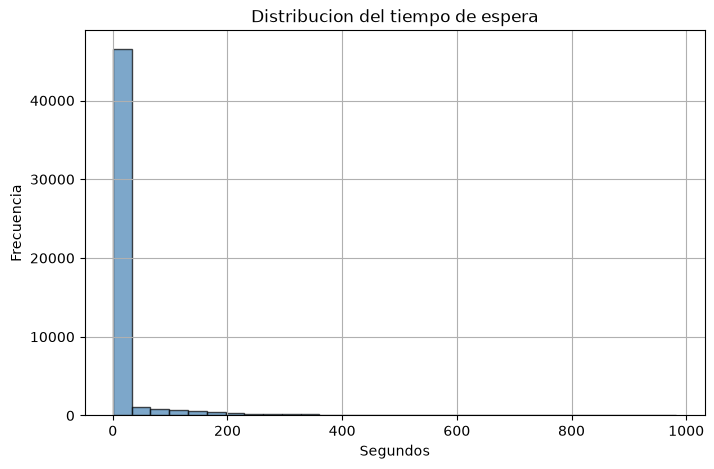

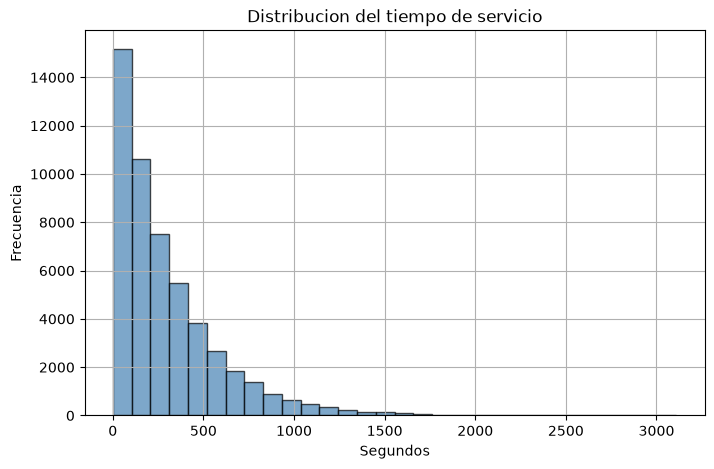

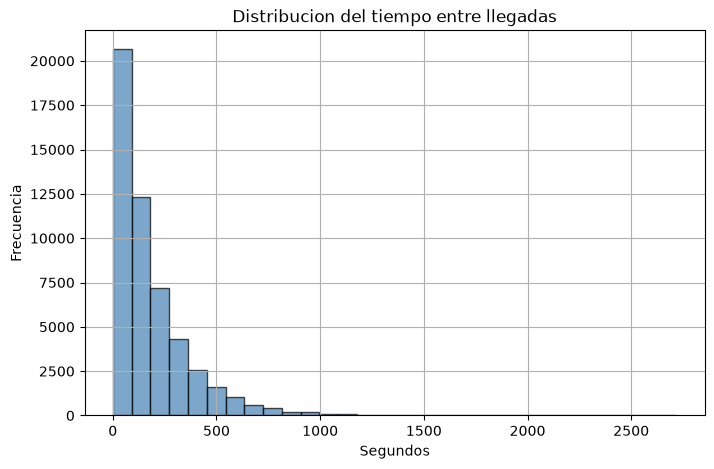

In [5]:
plt.figure(figsize=(8, 5))
plt.hist(espera, bins=30, color="steelblue", edgecolor="black", alpha=0.7)
plt.title("Distribucion del tiempo de espera")
plt.xlabel("Segundos"); plt.ylabel("Frecuencia"); plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(servicio, bins=30, color="steelblue", edgecolor="black", alpha=0.7)
plt.title("Distribucion del tiempo de servicio")
plt.xlabel("Segundos"); plt.ylabel("Frecuencia"); plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(entre_llegadas, bins=30, color="steelblue", edgecolor="black", alpha=0.7)
plt.title("Distribucion del tiempo entre llegadas")
plt.xlabel("Segundos"); plt.ylabel("Frecuencia"); plt.grid(True)
plt.show()

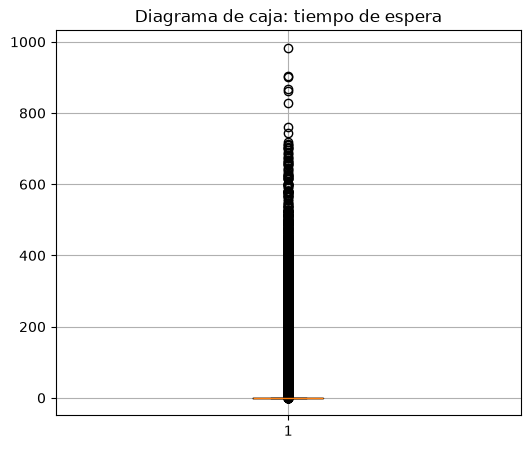

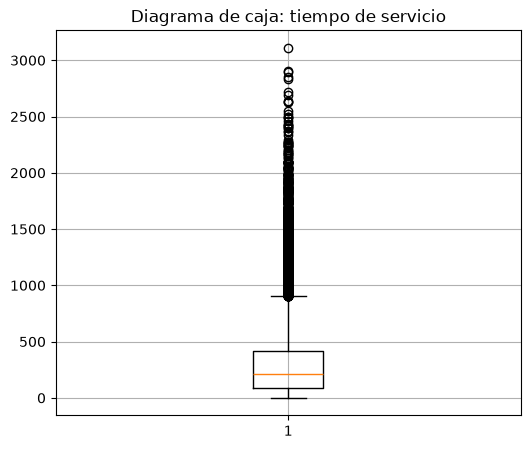

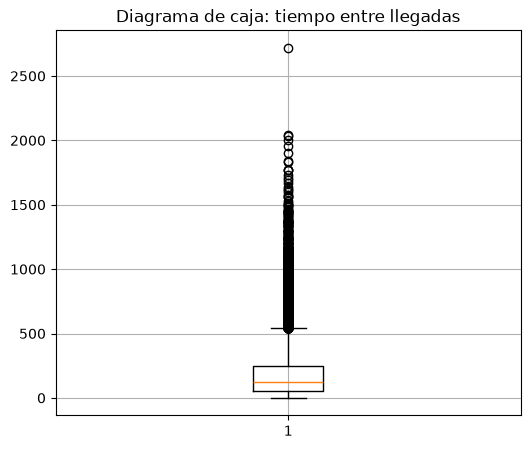

In [6]:
plt.figure(figsize=(6, 5))
plt.boxplot(espera)
plt.title("Diagrama de caja: tiempo de espera")
plt.grid(True)
plt.show()

plt.figure(figsize=(6, 5))
plt.boxplot(servicio)
plt.title("Diagrama de caja: tiempo de servicio")
plt.grid(True)
plt.show()

plt.figure(figsize=(6, 5))
plt.boxplot(entre_llegadas)
plt.title("Diagrama de caja: tiempo entre llegadas")
plt.grid(True)
plt.show()

### Evolución mensual del cumplimiento del SLA — el hallazgo central del trabajo

In [7]:
df["cumple_si"] = df["cumple_estandar"] == "Si"
resumen_mensual = pd.DataFrame({
    "llamadas": df.groupby("mes").size(),
    "pct_cumple": df.groupby("mes")["cumple_si"].mean() * 100,
    "espera_prom": df.groupby("mes")["tiempo_espera_seg"].mean(),
}).reset_index()
nombres_mes = {"01":"Enero","02":"Febrero","03":"Marzo","04":"Abril","05":"Mayo","06":"Junio",
               "07":"Julio","08":"Agosto","09":"Septiembre","10":"Octubre","11":"Noviembre","12":"Diciembre"}
resumen_mensual["nombre_mes"] = resumen_mensual["mes"].str[5:7].map(nombres_mes)
resumen_mensual

,mes,llamadas,pct_cumple,espera_prom,nombre_mes
0,2021-01,3000,97.47,5.38,Enero
1,2021-02,3061,97.52,4.36,Febrero
2,2021-03,3613,97.23,5.66,Marzo
3,2021-04,3642,97.17,4.79,Abril
4,2021-05,3619,95.77,7.98,Mayo
5,2021-06,4012,95.01,9.22,Junio
6,2021-07,4340,93.96,11.79,Julio
7,2021-08,4563,92.09,16.16,Agosto
8,2021-09,5022,89.88,21.54,Septiembre
9,2021-10,4988,88.23,27.89,Octubre


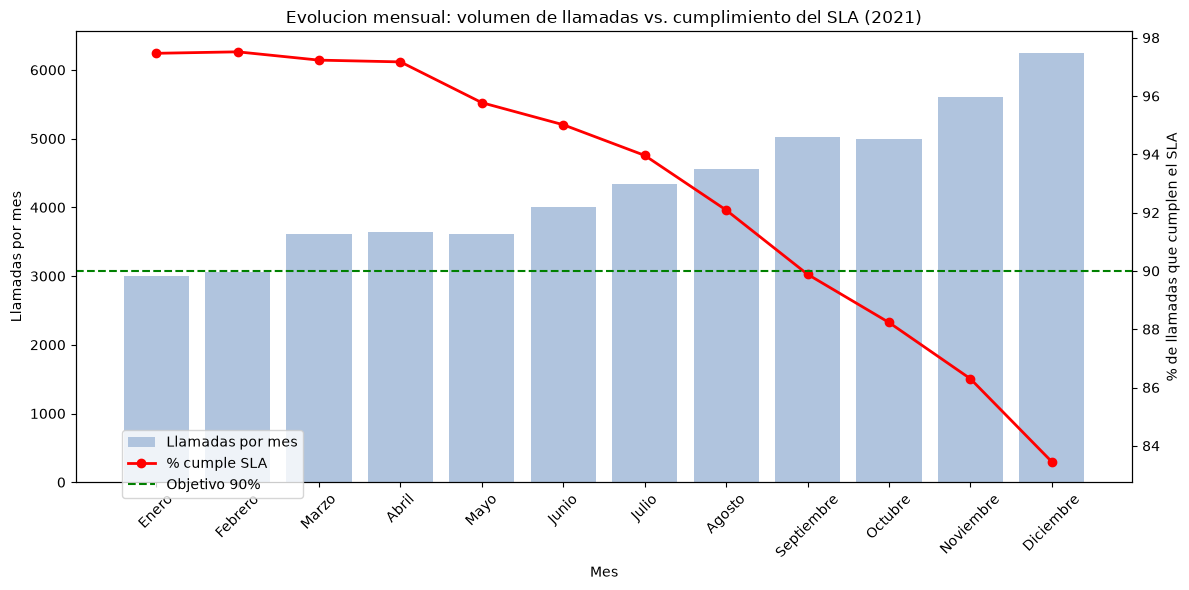

In [8]:
fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.bar(resumen_mensual["nombre_mes"], resumen_mensual["llamadas"], color="lightsteelblue", label="Llamadas por mes")
ax1.set_xlabel("Mes"); ax1.set_ylabel("Llamadas por mes")
ax1.tick_params(axis="x", rotation=45)

ax2 = ax1.twinx()
ax2.plot(resumen_mensual["nombre_mes"], resumen_mensual["pct_cumple"], color="red", marker="o", linewidth=2, label="% cumple SLA")
ax2.axhline(90, color="green", linestyle="--", label="Objetivo 90%")
ax2.set_ylabel("% de llamadas que cumplen el SLA")

plt.title("Evolucion mensual: volumen de llamadas vs. cumplimiento del SLA (2021)")
fig.legend(loc="lower left", bbox_to_anchor=(0.1, 0.15))
plt.tight_layout()
plt.show()

El cumplimiento cae por debajo del objetivo del 90% a partir de septiembre de 2021.

## 3. Distribuciones seleccionadas: Exponencial

In [9]:
media_servicio = servicio.mean()
media_llegadas = entre_llegadas.mean()

print(f"Tiempo de servicio      -> media={media_servicio:.2f}s, std={servicio.std():.2f}s")
print(f"Tiempo entre llegadas   -> media={media_llegadas:.2f}s, std={entre_llegadas.std():.2f}s")
print("(la Exponencial teorica tiene media = desviacion estandar)")

ks_servicio = kstest(servicio, "expon", args=(0, media_servicio))
ks_llegadas = kstest(entre_llegadas, "expon", args=(0, media_llegadas))
print(f"\nK-S servicio:      D={ks_servicio.statistic:.4f}, p={ks_servicio.pvalue:.4f}")
print(f"K-S entre llegadas: D={ks_llegadas.statistic:.4f}, p={ks_llegadas.pvalue:.4f}")

Tiempo de servicio      -> media=299.10s, std=299.87s
Tiempo entre llegadas   -> media=180.58s, std=188.05s
(la Exponencial teorica tiene media = desviacion estandar)

K-S servicio:      D=0.0029, p=0.7734
K-S entre llegadas: D=0.0119, p=0.0000


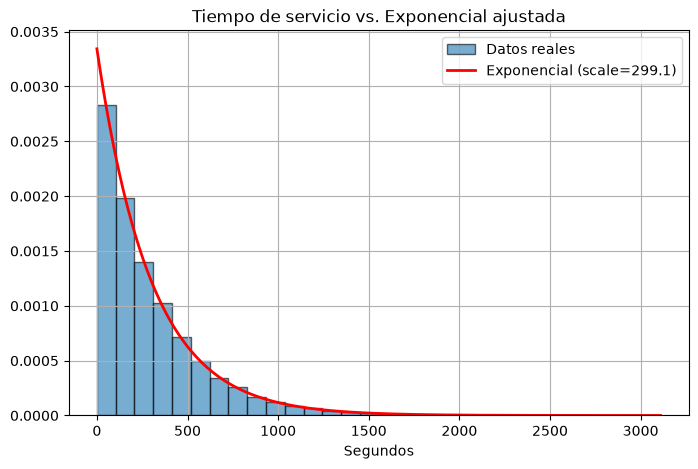

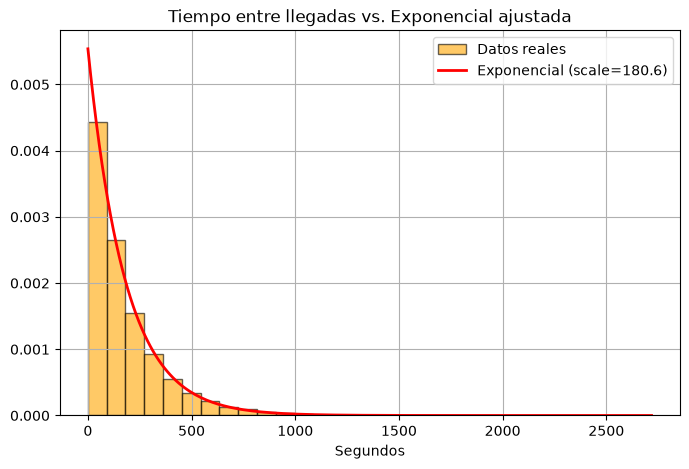

In [10]:
x1 = np.linspace(0, servicio.max(), 200)
plt.figure(figsize=(8, 5))
plt.hist(servicio, bins=30, density=True, edgecolor="black", alpha=0.6, label="Datos reales")
plt.plot(x1, expon.pdf(x1, scale=media_servicio), color="red", linewidth=2, label=f"Exponencial (scale={media_servicio:.1f})")
plt.title("Tiempo de servicio vs. Exponencial ajustada")
plt.xlabel("Segundos"); plt.legend(); plt.grid(True)
plt.show()

x2 = np.linspace(0, entre_llegadas.max(), 200)
plt.figure(figsize=(8, 5))
plt.hist(entre_llegadas, bins=30, density=True, edgecolor="black", alpha=0.6, color="orange", label="Datos reales")
plt.plot(x2, expon.pdf(x2, scale=media_llegadas), color="red", linewidth=2, label=f"Exponencial (scale={media_llegadas:.1f})")
plt.title("Tiempo entre llegadas vs. Exponencial ajustada")
plt.xlabel("Segundos"); plt.legend(); plt.grid(True)
plt.show()

## 4. Modelo computacional: motor de simulación

In [11]:
SLA_SEGUNDOS = 60
N_AGENTES_AS_IS = 4

MU = 1 / media_servicio
diciembre = df[df["fecha"].str.startswith("2021-12")]
LAMBDA_DICIEMBRE = 1 / diciembre["tiempo_entre_llegadas_seg"].mean()
N_LLAMADAS_DICIEMBRE = len(diciembre)

print(f"lambda (diciembre) = {LAMBDA_DICIEMBRE:.5f} llamadas/seg")
print(f"mu (todo el anio)  = {MU:.5f} llamadas/seg")
print(f"n_agentes = {N_AGENTES_AS_IS}, n_llamadas (diciembre) = {N_LLAMADAS_DICIEMBRE}")

lambda (diciembre) = 0.00758 llamadas/seg
mu (todo el anio)  = 0.00334 llamadas/seg
n_agentes = 4, n_llamadas (diciembre) = 6249


In [12]:
def simular_call_center(lam, mu, n_agentes, n_llamadas, semilla):
    """Motor de eventos discretos: asigna cada llamada al agente libre mas pronto."""
    np.random.seed(semilla)
    tiempos_entre_llegadas = np.random.exponential(scale=1 / lam, size=n_llamadas)
    tiempos_servicio = np.random.exponential(scale=1 / mu, size=n_llamadas)
    tiempos_llegada = np.cumsum(tiempos_entre_llegadas)

    tiempo_libre_agente = np.zeros(n_agentes)
    inicio_atencion = np.zeros(n_llamadas)
    fin_atencion = np.zeros(n_llamadas)
    espera = np.zeros(n_llamadas)

    for i in range(n_llamadas):
        agente = np.argmin(tiempo_libre_agente)
        inicio_atencion[i] = max(tiempos_llegada[i], tiempo_libre_agente[agente])
        fin_atencion[i] = inicio_atencion[i] + tiempos_servicio[i]
        espera[i] = inicio_atencion[i] - tiempos_llegada[i]
        tiempo_libre_agente[agente] = fin_atencion[i]

    tiempo_total = fin_atencion[-1] - tiempos_llegada[0]
    resultado = {
        "espera_promedio": espera.mean(),
        "pct_cumple_sla": (espera <= SLA_SEGUNDOS).mean() * 100,
        "utilizacion_teorica": lam / (n_agentes * mu) * 100,
        "utilizacion_simulada": np.sum(tiempos_servicio) / (n_agentes * tiempo_total) * 100,
    }
    return resultado, espera

### Corrida de demostración y validación contra el dato real

In [13]:
resultado_demo, espera_demo = simular_call_center(
    LAMBDA_DICIEMBRE, MU, N_AGENTES_AS_IS, N_LLAMADAS_DICIEMBRE, semilla=42
)
espera_real_dic = diciembre["tiempo_espera_seg"]
pct_cumple_real_dic = (diciembre["cumple_estandar"] == "Si").mean() * 100

print("=== Simulado (semilla 42) vs. Real (diciembre 2021) ===")
print(f"Espera promedio: {resultado_demo['espera_promedio']:.2f}s  vs  {espera_real_dic.mean():.2f}s")
print(f"% cumple SLA:    {resultado_demo['pct_cumple_sla']:.2f}%  vs  {pct_cumple_real_dic:.2f}%")
print(f"Utilizacion:     teorica {resultado_demo['utilizacion_teorica']:.2f}%  |  simulada {resultado_demo['utilizacion_simulada']:.2f}%")

estadistico_ks, p_valor_ks = ks_2samp(espera_demo, espera_real_dic)
print(f"\nPrueba K-S (2 muestras), simulado vs. real: D={estadistico_ks:.4f}, p-valor={p_valor_ks:.4f}")
print("No se rechaza H0 (la distribucion simulada es consistente con la real)" if p_valor_ks > 0.05 else "Se rechaza H0")

=== Simulado (semilla 42) vs. Real (diciembre 2021) ===
Espera promedio: 36.45s  vs  35.54s
% cumple SLA:    83.85%  vs  83.45%
Utilizacion:     teorica 56.71%  |  simulada 56.17%

Prueba K-S (2 muestras), simulado vs. real: D=0.0086, p-valor=0.9738
No se rechaza H0 (la distribucion simulada es consistente con la real)


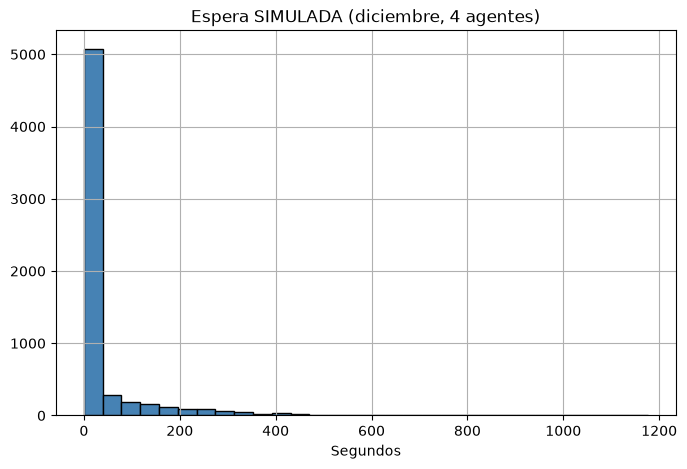

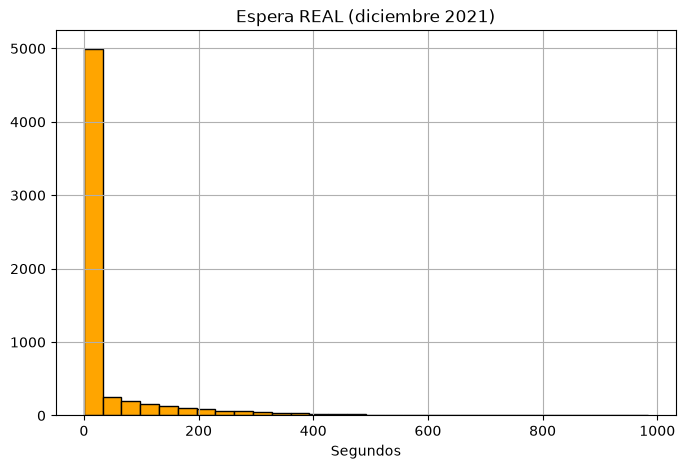

In [14]:
plt.figure(figsize=(8, 5))
plt.hist(espera_demo, bins=30, color="steelblue", edgecolor="black")
plt.title("Espera SIMULADA (diciembre, 4 agentes)")
plt.xlabel("Segundos"); plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(espera_real_dic, bins=30, color="orange", edgecolor="black")
plt.title("Espera REAL (diciembre 2021)")
plt.xlabel("Segundos"); plt.grid(True)
plt.show()

### 30 réplicas del escenario AS-IS

In [15]:
N_REPLICAS = 30
filas_replicas = []
for r in range(N_REPLICAS):
    res, _ = simular_call_center(LAMBDA_DICIEMBRE, MU, N_AGENTES_AS_IS, N_LLAMADAS_DICIEMBRE, semilla=100 + r)
    res["replica"] = r + 1
    filas_replicas.append(res)

df_replicas = pd.DataFrame(filas_replicas)
df_replicas[["espera_promedio", "pct_cumple_sla"]].describe().round(2)

,espera_promedio,pct_cumple_sla
count,30.00,30.00
mean,43.21,82.59
std,6.37,1.42
min,32.77,79.77
25%,38.94,81.59
50%,43.08,82.53
75%,46.04,83.39
max,60.38,85.52


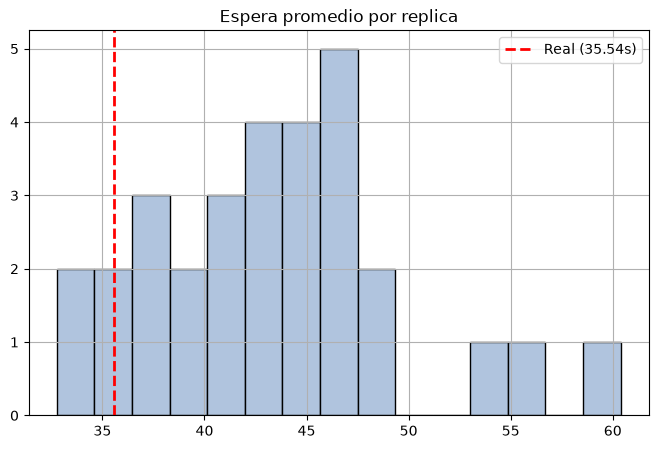

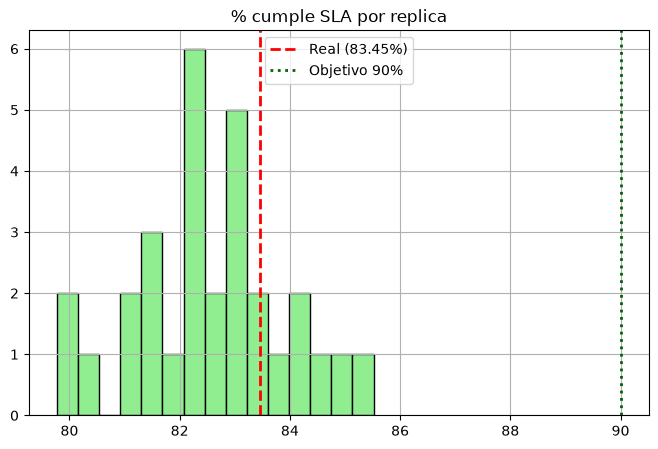

In [16]:
plt.figure(figsize=(8, 5))
plt.hist(df_replicas["espera_promedio"], bins=15, color="lightsteelblue", edgecolor="black")
plt.axvline(espera_real_dic.mean(), color="red", linestyle="--", linewidth=2, label=f"Real ({espera_real_dic.mean():.2f}s)")
plt.title("Espera promedio por replica"); plt.legend(); plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(df_replicas["pct_cumple_sla"], bins=15, color="lightgreen", edgecolor="black")
plt.axvline(pct_cumple_real_dic, color="red", linestyle="--", linewidth=2, label=f"Real ({pct_cumple_real_dic:.2f}%)")
plt.axvline(90, color="darkgreen", linestyle=":", linewidth=2, label="Objetivo 90%")
plt.title("% cumple SLA por replica"); plt.legend(); plt.grid(True)
plt.show()

### Validación contra los 12 meses reales 

In [17]:
filas_validacion = []
for mes_actual in sorted(df["mes"].unique()):
    datos_mes = df[df["mes"] == mes_actual]
    lam_mes = 1 / datos_mes["tiempo_entre_llegadas_seg"].mean()
    pct_real_mes = (datos_mes["cumple_estandar"] == "Si").mean() * 100
    resultados_mes = [
        simular_call_center(lam_mes, MU, N_AGENTES_AS_IS, len(datos_mes), semilla=200 + r)[0]["pct_cumple_sla"]
        for r in range(10)
    ]
    filas_validacion.append({"mes": mes_actual, "pct_cumple_real": round(pct_real_mes, 2),
                              "pct_cumple_simulado": round(np.mean(resultados_mes), 2)})

df_validacion = pd.DataFrame(filas_validacion)
df_validacion["diferencia"] = (df_validacion["pct_cumple_simulado"] - df_validacion["pct_cumple_real"]).round(2)
df_validacion

,mes,pct_cumple_real,pct_cumple_simulado,diferencia
0,2021-01,97.47,97.59,0.12
1,2021-02,97.52,97.23,-0.29
2,2021-03,97.23,97.10,-0.13
3,2021-04,97.17,96.39,-0.78
4,2021-05,95.77,96.03,0.26
5,2021-06,95.01,95.05,0.04
6,2021-07,93.96,93.52,-0.44
7,2021-08,92.09,92.45,0.36
8,2021-09,89.88,90.06,0.18
9,2021-10,88.23,88.11,-0.12


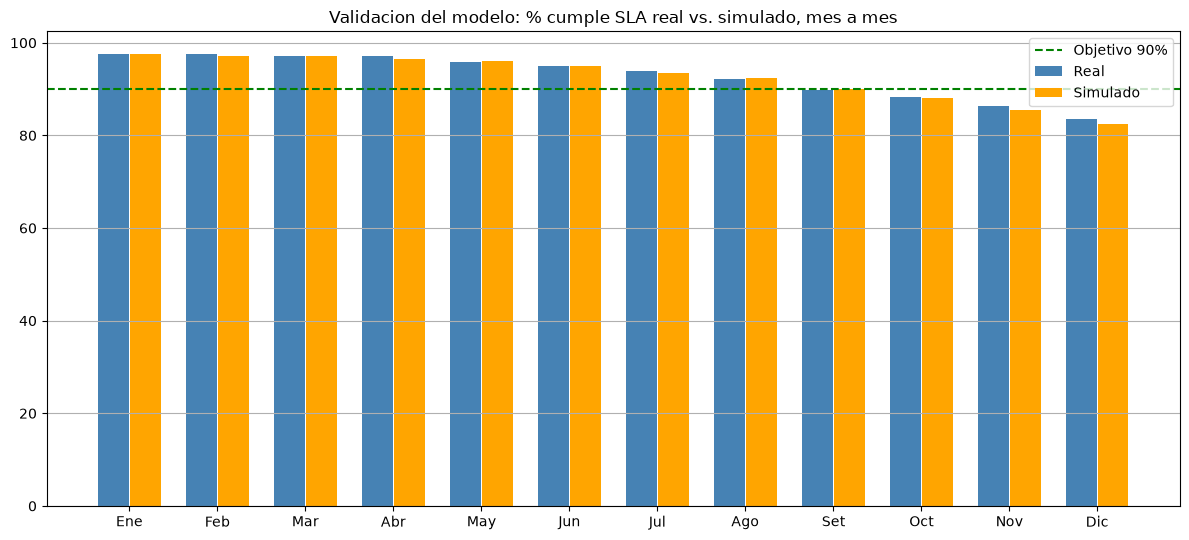

In [18]:
nombres_cortos = ["Ene","Feb","Mar","Abr","May","Jun","Jul","Ago","Set","Oct","Nov","Dic"]
x = np.arange(12)
plt.figure(figsize=(12, 5.5))
plt.bar(x - 0.18, df_validacion["pct_cumple_real"], width=0.35, label="Real", color="steelblue")
plt.bar(x + 0.18, df_validacion["pct_cumple_simulado"], width=0.35, label="Simulado", color="orange")
plt.axhline(90, color="green", linestyle="--", label="Objetivo 90%")
plt.xticks(x, nombres_cortos)
plt.title("Validacion del modelo: % cumple SLA real vs. simulado, mes a mes")
plt.legend(); plt.grid(True, axis="y")
plt.tight_layout()
plt.show()

## 5. Escenarios What-If

In [19]:
enero = df[df["fecha"].str.startswith("2021-01")]
escenarios = {
    "Optimista (enero)": {"lam": 1 / enero["tiempo_entre_llegadas_seg"].mean(), "n": len(enero)},
    "Normal (promedio anual)": {"lam": 1 / df["tiempo_entre_llegadas_seg"].mean(), "n": round(len(df) / 12)},
    "Pesimista (diciembre)": {"lam": LAMBDA_DICIEMBRE, "n": N_LLAMADAS_DICIEMBRE},
}
filas_escenarios = []
for nombre, params in escenarios.items():
    resultados = [simular_call_center(params["lam"], MU, N_AGENTES_AS_IS, params["n"], semilla=300+r)[0] for r in range(N_REPLICAS)]
    dfr = pd.DataFrame(resultados)
    filas_escenarios.append({"escenario": nombre, "espera_promedio": dfr["espera_promedio"].mean(),
                              "pct_cumple_sla": dfr["pct_cumple_sla"].mean()})
df_escenarios = pd.DataFrame(filas_escenarios)
df_escenarios

,escenario,espera_promedio,pct_cumple_sla
0,Optimista (enero),4.17,97.82
1,Normal (promedio anual),12.79,93.67
2,Pesimista (diciembre),43.17,82.39


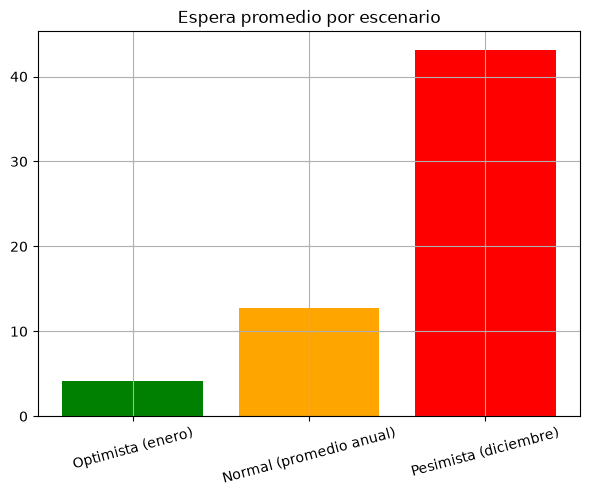

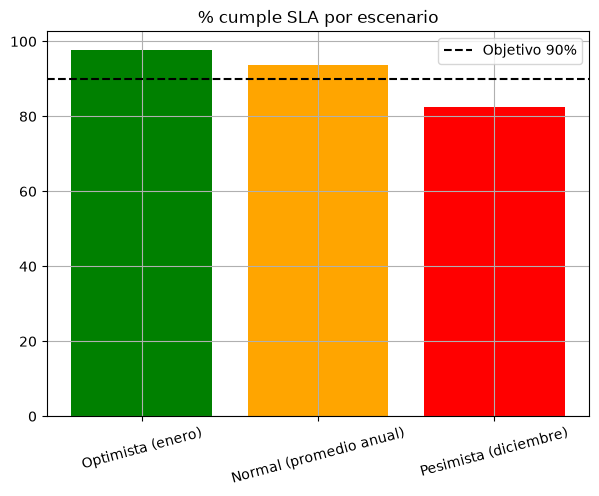

In [20]:
plt.figure(figsize=(7, 5))
plt.bar(df_escenarios["escenario"], df_escenarios["espera_promedio"], color=["green","orange","red"])
plt.title("Espera promedio por escenario"); plt.xticks(rotation=15); plt.grid(True)
plt.show()

plt.figure(figsize=(7, 5))
plt.bar(df_escenarios["escenario"], df_escenarios["pct_cumple_sla"], color=["green","orange","red"])
plt.axhline(90, color="black", linestyle="--", label="Objetivo 90%")
plt.title("% cumple SLA por escenario"); plt.xticks(rotation=15); plt.legend(); plt.grid(True)
plt.show()

## 6. Propuesta TO-BE: ¿cuántos agentes hacen falta?

In [21]:
filas_to_be = []
for n_agentes in range(4, 9):
    resultados = [simular_call_center(LAMBDA_DICIEMBRE, MU, n_agentes, N_LLAMADAS_DICIEMBRE, semilla=300+r)[0] for r in range(N_REPLICAS)]
    dfr = pd.DataFrame(resultados)
    filas_to_be.append({"n_agentes": n_agentes, "espera_promedio": dfr["espera_promedio"].mean(),
                         "pct_cumple_sla": dfr["pct_cumple_sla"].mean(),
                         "utilizacion_simulada": dfr["utilizacion_simulada"].mean()})
df_to_be = pd.DataFrame(filas_to_be)
df_to_be["cumple_objetivo_90"] = df_to_be["pct_cumple_sla"] >= 90
minimo_agentes = int(df_to_be[df_to_be["cumple_objetivo_90"]].iloc[0]["n_agentes"])
print(f"Numero minimo de agentes para cumplir el 90%: {minimo_agentes}")
df_to_be

Numero minimo de agentes para cumplir el 90%: 5


,n_agentes,espera_promedio,pct_cumple_sla,utilizacion_simulada,cumple_objetivo_90
0,4,43.17,82.39,56.91,False
1,5,10.51,94.43,45.53,True
2,6,2.62,98.43,37.94,True
3,7,0.62,99.61,32.52,True
4,8,0.14,99.91,28.46,True


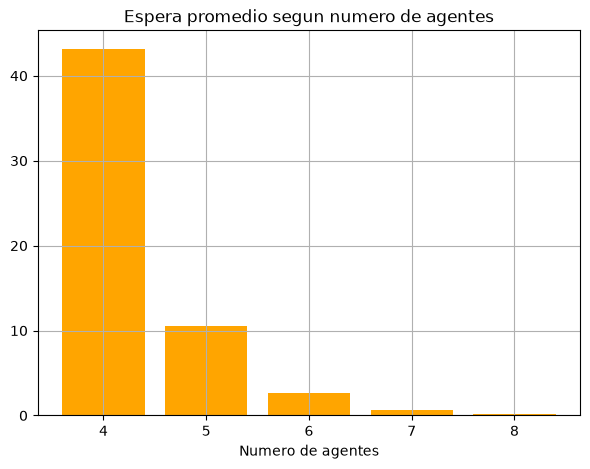

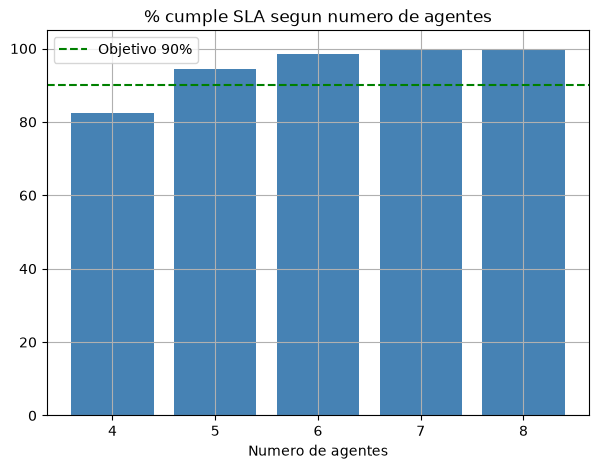

In [22]:
plt.figure(figsize=(7, 5))
plt.bar(df_to_be["n_agentes"].astype(str), df_to_be["espera_promedio"], color="orange")
plt.title("Espera promedio segun numero de agentes"); plt.xlabel("Numero de agentes"); plt.grid(True)
plt.show()

plt.figure(figsize=(7, 5))
plt.bar(df_to_be["n_agentes"].astype(str), df_to_be["pct_cumple_sla"], color="steelblue")
plt.axhline(90, color="green", linestyle="--", label="Objetivo 90%")
plt.title("% cumple SLA segun numero de agentes"); plt.xlabel("Numero de agentes"); plt.legend(); plt.grid(True)
plt.show()

## 7. Comparación final: AS-IS vs. TO-BE

In [23]:
as_is = df_to_be[df_to_be["n_agentes"] == 4].iloc[0]
to_be = df_to_be[df_to_be["n_agentes"] == minimo_agentes].iloc[0]
comparacion = pd.DataFrame({
    "Indicador": ["Espera promedio (s)", "% cumple SLA", "Utilizacion simulada (%)"],
    "AS-IS (4 agentes)": [as_is["espera_promedio"], as_is["pct_cumple_sla"], as_is["utilizacion_simulada"]],
    f"TO-BE ({minimo_agentes} agentes)": [to_be["espera_promedio"], to_be["pct_cumple_sla"], to_be["utilizacion_simulada"]],
})
comparacion

,Indicador,AS-IS (4 agentes),TO-BE (5 agentes)
0,Espera promedio (s),43.17,10.51
1,% cumple SLA,82.39,94.43
2,Utilizacion simulada (%),56.91,45.53


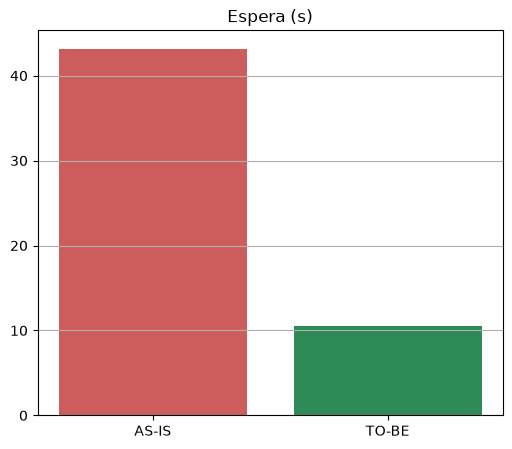

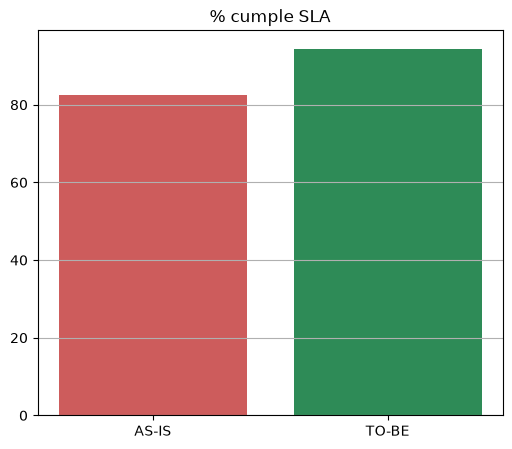

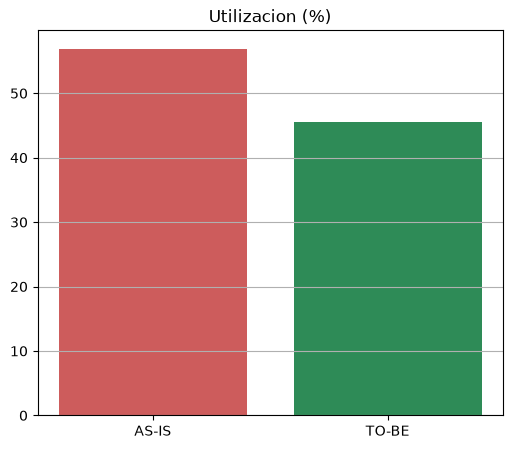

In [24]:
plt.figure(figsize=(6, 5))
plt.bar(["AS-IS", "TO-BE"], [as_is["espera_promedio"], to_be["espera_promedio"]], color=["indianred", "seagreen"])
plt.title("Espera (s)"); plt.grid(True, axis="y")
plt.show()

plt.figure(figsize=(6, 5))
plt.bar(["AS-IS", "TO-BE"], [as_is["pct_cumple_sla"], to_be["pct_cumple_sla"]], color=["indianred", "seagreen"])
plt.title("% cumple SLA"); plt.grid(True, axis="y")
plt.show()

plt.figure(figsize=(6, 5))
plt.bar(["AS-IS", "TO-BE"], [as_is["utilizacion_simulada"], to_be["utilizacion_simulada"]], color=["indianred", "seagreen"])
plt.title("Utilizacion (%)"); plt.grid(True, axis="y")
plt.show()

## Conclusión

Con un único agente adicional durante los periodos de alta demanda, el call center recupera el
cumplimiento del SLA y reduce la espera promedio en más de 75%, con una implementación de baja
complejidad operativa (no requiere rediseñar el proceso ni adquirir tecnología nueva).